# Modelos PyTorch — Classificação de Texto AI vs Human

Este notebook permite treinar e avaliar os modelos PyTorch implementados em `models/pytorch_models/`.

**Modelos disponíveis:**
- **Baseline** — Regressão Logística (TF-IDF)
- **DNN** — Deep Feedforward Network (TF-IDF)
- **LSTM** — Bidirectional LSTM com Embeddings
- **GRU** — Bidirectional GRU com Embeddings

**Classes:** Anthropic | Google | Human | Meta | OpenAI

## 0. Setup — Imports e Configuração

In [57]:
import sys
import importlib
sys.path.append('../models/pytorch_models')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import dataset as dataset_module
import models as models_module
import train as train_module

importlib.reload(dataset_module)
importlib.reload(models_module)
importlib.reload(train_module)

from dataset import TfidfDataset, SequenceDataset, clean_text, build_vocab
from models import BaselineClassifier, DNNClassifier, LSTMClassifier, GRUClassifier
from train import train, evaluate, predict, DEVICE

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"train() aceita weight_decay: {'weight_decay' in train.__code__.co_varnames}")

[pytorch_models] Using device: cpu
PyTorch version: 2.10.0
Device: cpu
train() aceita weight_decay: True


In [58]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Seed fixada em {SEED}")

Seed fixada em 42


In [59]:
# Hiperparâmetros 

CLASSES       = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
N_CLASSES     = len(CLASSES)

TFIDF_WORDS   = 5000     # tamanho do vocabulário TF-IDF (bigrams incluídos)
MAX_LEN       = 200      # comprimento máximo de sequência (RNN/LSTM/GRU)
MAX_VOCAB     = 20000    # tamanho do vocabulário para embeddings
EMBED_DIM     = 128      # dimensão dos embeddings
HIDDEN_DIM    = 256      # dimensão do estado oculto das RNNs

BATCH_SIZE    = 64
EPOCHS        = 100
LR            = 0.001
PATIENCE      = 15       # early stopping (melhor modelo restaurado automaticamente)

TEST_SIZE     = 0.2
VAL_SIZE      = 0.1
RANDOM_STATE  = 42

print("Configuração carregada!")

Configuração carregada!


## 1. Carregar e Preparar os Dados

- **Treino + Validação:** `dataset_limpo.csv`
- **Teste final:** `dataset-exemplos.csv` (como no notebook NumPy)

Total de exemplos (dataset_limpo): 4995

Distribuição por classe (dataset_limpo):


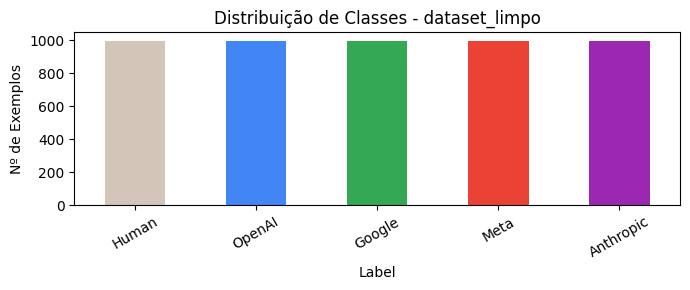


Total de exemplos (dataset-exemplos): 125
Distribuição por classe (dataset-exemplos):
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64


In [47]:
# Carregar datasets
df = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])
df_exemplos = pd.read_csv('../data/dataset-exemplos.csv', sep=';').dropna(subset=['Text', 'Label'])

label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}

texts  = df['Text'].tolist()
labels = [label2idx[l] for l in df['Label']]

print(f"Total de exemplos (dataset_limpo): {len(texts)}")
print("\nDistribuição por classe (dataset_limpo):")
df['Label'].value_counts().plot(kind='bar', color=['#D4C5B9', '#4285F4', '#34A853', '#EA4335', '#9C27B0'],
                                 figsize=(7, 3), title='Distribuição de Classes - dataset_limpo')
plt.ylabel('Nº de Exemplos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"\nTotal de exemplos (dataset-exemplos): {len(df_exemplos)}")
print("Distribuição por classe (dataset-exemplos):")
print(df_exemplos['Label'].value_counts())

In [48]:
# Split treino / validação (teste externo = dataset-exemplos)
X_tr, X_val, y_tr, y_val = train_test_split(
    texts, labels, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=labels)

# Teste externo (dataset do professor), sem entrar no treino/validação
X_te = df_exemplos['Text'].tolist()
y_te = [label2idx[l] for l in df_exemplos['Label']]

print(f"Treino:    {len(X_tr)} exemplos")
print(f"Validação: {len(X_val)} exemplos")
print(f"Teste (externo - professor): {len(X_te)} exemplos")

Treino:    4495 exemplos
Validação: 500 exemplos
Teste (externo - professor): 125 exemplos


In [49]:
# Datasets TF-IDF (para Baseline e DNN)
train_ds_tfidf = TfidfDataset(X_tr,  y_tr,  max_words=TFIDF_WORDS, train=True)
val_ds_tfidf   = TfidfDataset(X_val, y_val, vectorizer=train_ds_tfidf.vectorizer, train=False)
test_ds_tfidf  = TfidfDataset(X_te,  y_te,  vectorizer=train_ds_tfidf.vectorizer, train=False)

train_loader_tfidf = DataLoader(train_ds_tfidf, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tfidf   = DataLoader(val_ds_tfidf,   batch_size=BATCH_SIZE)
test_loader_tfidf  = DataLoader(test_ds_tfidf,  batch_size=BATCH_SIZE)

# Datasets de Sequências (para LSTM / GRU)
clean_tr  = [clean_text(t) for t in X_tr]
word_index = build_vocab(clean_tr, max_words=MAX_VOCAB)
vocab_size = len(word_index) + 2

train_ds_seq = SequenceDataset(X_tr,  y_tr,  word_index, max_len=MAX_LEN)
val_ds_seq   = SequenceDataset(X_val, y_val, word_index, max_len=MAX_LEN)
test_ds_seq  = SequenceDataset(X_te,  y_te,  word_index, max_len=MAX_LEN)

train_loader_seq = DataLoader(train_ds_seq, batch_size=BATCH_SIZE, shuffle=True)
val_loader_seq   = DataLoader(val_ds_seq,   batch_size=BATCH_SIZE)
test_loader_seq  = DataLoader(test_ds_seq,  batch_size=BATCH_SIZE)

print(f"Vocabulário (Embeddings): {vocab_size} palavras")
print("Conjunto de teste externo configurado a partir de dataset-exemplos.csv")

Vocabulário (Embeddings): 20002 palavras
Conjunto de teste externo configurado a partir de dataset-exemplos.csv


## Funções de Visualização

In [50]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Treino',    color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Validação', color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Treino',    color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Validação', color='tomato')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion(model, loader, title='Matriz de Confusão'):
    preds = predict(model, loader).numpy()
    true  = [int(y) for _, y in loader.dataset]
    cm = confusion_matrix(true, preds)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title, fontweight='bold')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.tight_layout()
    plt.show()

    print(classification_report(true, preds, target_names=CLASSES))


---
## 2. Baseline — Regressão Logística (TF-IDF)

In [51]:
baseline = BaselineClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES)
criterion = nn.CrossEntropyLoss()

print("A treinar a Baseline (Regressão Logística + TF-IDF)...")
history_base = train(baseline, train_loader_tfidf, val_loader_tfidf, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar a Baseline (Regressão Logística + TF-IDF)...
Epoch 1/100 | train_loss: 1.5432 | train_acc: 0.6810 | val_loss: 1.5531 | val_acc: 0.5500
Epoch 2/100 | train_loss: 1.4825 | train_acc: 0.7982 | val_loss: 1.5035 | val_acc: 0.6500
Epoch 3/100 | train_loss: 1.4268 | train_acc: 0.8329 | val_loss: 1.4584 | val_acc: 0.6880
Epoch 4/100 | train_loss: 1.3746 | train_acc: 0.8521 | val_loss: 1.4166 | val_acc: 0.6960
Epoch 5/100 | train_loss: 1.3253 | train_acc: 0.8638 | val_loss: 1.3781 | val_acc: 0.7180
Epoch 6/100 | train_loss: 1.2817 | train_acc: 0.8736 | val_loss: 1.3424 | val_acc: 0.7320
Epoch 7/100 | train_loss: 1.2376 | train_acc: 0.8794 | val_loss: 1.3091 | val_acc: 0.7320
Epoch 8/100 | train_loss: 1.1980 | train_acc: 0.8903 | val_loss: 1.2786 | val_acc: 0.7380
Epoch 9/100 | train_loss: 1.1602 | train_acc: 0.8966 | val_loss: 1.2494 | val_acc: 0.7440
Epoch 10/100 | train_loss: 1.1245 | train_acc: 0.9008 | val_loss: 1.2224 | val_acc: 0.7460
Epoch 11/100 | train_loss: 1.0897 | train_ac

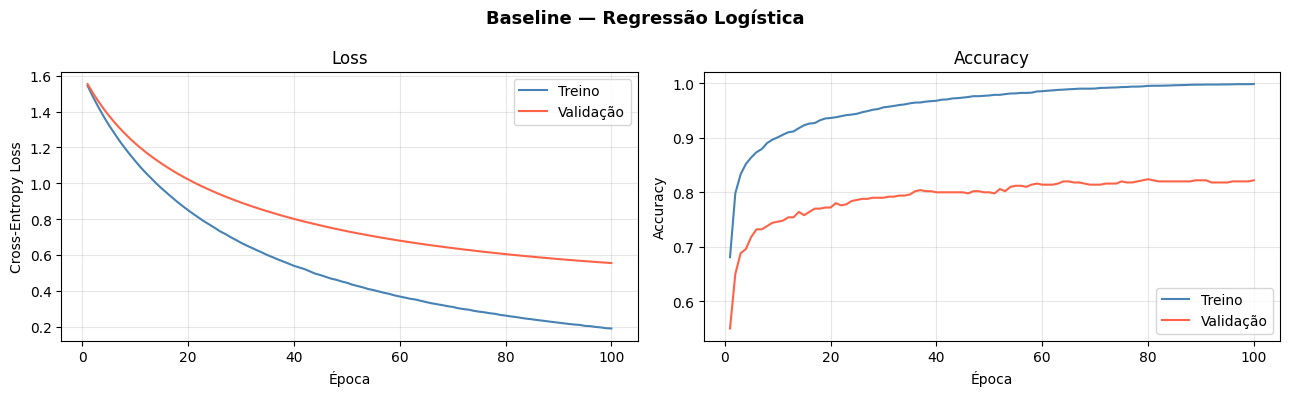


Accuracy no Teste (Baseline): 54.40%


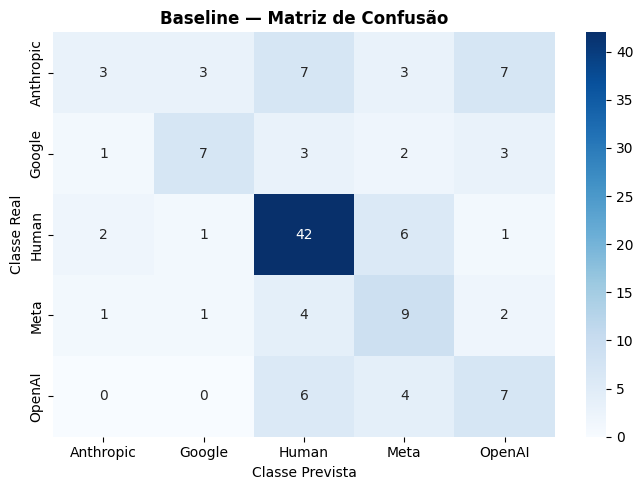

              precision    recall  f1-score   support

   Anthropic       0.43      0.13      0.20        23
      Google       0.58      0.44      0.50        16
       Human       0.68      0.81      0.74        52
        Meta       0.38      0.53      0.44        17
      OpenAI       0.35      0.41      0.38        17

    accuracy                           0.54       125
   macro avg       0.48      0.46      0.45       125
weighted avg       0.53      0.54      0.52       125



In [52]:
plot_history(history_base, 'Baseline — Regressão Logística')
_, acc_base = evaluate(baseline, test_loader_tfidf)
print(f"\nAccuracy no Teste (Baseline): {acc_base*100:.2f}%")
plot_confusion(baseline, test_loader_tfidf, 'Baseline — Matriz de Confusão')

---
## 3. DNN — Deep Feedforward Network (TF-IDF)

In [53]:
dnn = DNNClassifier(
    input_dim=TFIDF_WORDS,
    n_classes=N_CLASSES,
    topology=[256, 128, 64],   # camadas ocultas
    dropout=0.3
)

print("A treinar DNN (TF-IDF)...")
history_dnn = train(dnn, train_loader_tfidf, val_loader_tfidf, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar DNN (TF-IDF)...
Epoch 1/100 | train_loss: 1.0134 | train_acc: 0.5666 | val_loss: 1.0692 | val_acc: 0.5520
Epoch 2/100 | train_loss: 0.4595 | train_acc: 0.8518 | val_loss: 0.6432 | val_acc: 0.7580
Epoch 3/100 | train_loss: 0.1884 | train_acc: 0.9499 | val_loss: 0.5559 | val_acc: 0.7960
Epoch 4/100 | train_loss: 0.0855 | train_acc: 0.9813 | val_loss: 0.6068 | val_acc: 0.8000
Epoch 5/100 | train_loss: 0.0371 | train_acc: 0.9942 | val_loss: 0.6835 | val_acc: 0.7900
Epoch 6/100 | train_loss: 0.0163 | train_acc: 0.9980 | val_loss: 0.7546 | val_acc: 0.7960
Epoch 7/100 | train_loss: 0.0098 | train_acc: 0.9984 | val_loss: 0.8458 | val_acc: 0.8080
Epoch 8/100 | train_loss: 0.0055 | train_acc: 0.9996 | val_loss: 0.8557 | val_acc: 0.7980
Epoch 9/100 | train_loss: 0.0025 | train_acc: 0.9998 | val_loss: 0.9179 | val_acc: 0.8060
Epoch 10/100 | train_loss: 0.0030 | train_acc: 0.9993 | val_loss: 0.9327 | val_acc: 0.8040
Epoch 11/100 | train_loss: 0.0040 | train_acc: 0.9987 | val_loss: 0.9942 

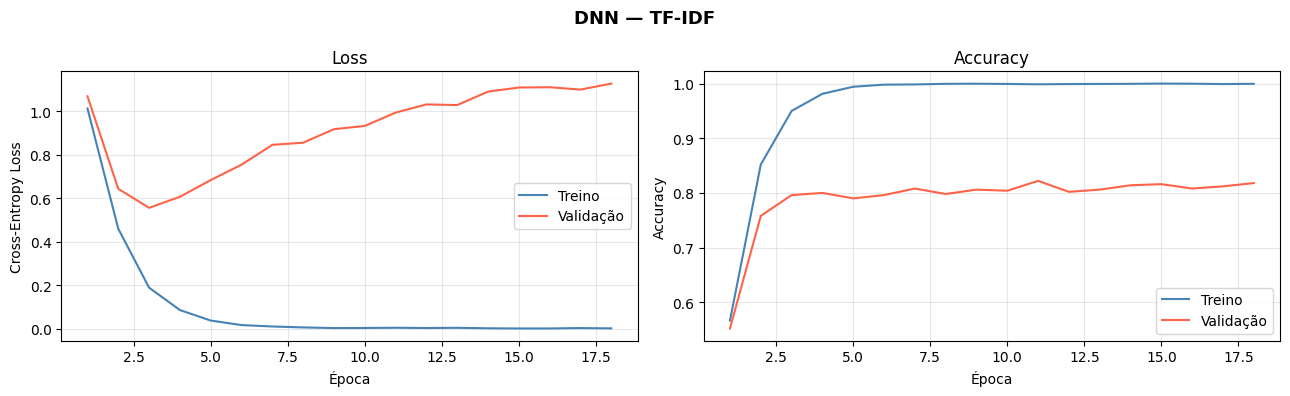


Accuracy no Teste (DNN): 52.00%


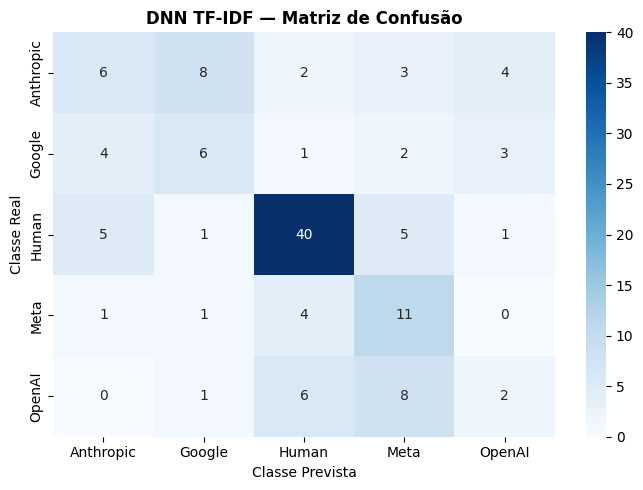

              precision    recall  f1-score   support

   Anthropic       0.38      0.26      0.31        23
      Google       0.35      0.38      0.36        16
       Human       0.75      0.77      0.76        52
        Meta       0.38      0.65      0.48        17
      OpenAI       0.20      0.12      0.15        17

    accuracy                           0.52       125
   macro avg       0.41      0.43      0.41       125
weighted avg       0.51      0.52      0.51       125



In [54]:
plot_history(history_dnn, 'DNN — TF-IDF')
_, acc_dnn = evaluate(dnn, test_loader_tfidf)
print(f"\nAccuracy no Teste (DNN): {acc_dnn*100:.2f}%")
plot_confusion(dnn, test_loader_tfidf, 'DNN TF-IDF — Matriz de Confusão')

---
## 4. BiLSTM — Embeddings

In [60]:
lstm = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=1,
    dropout=0.2,
    bidirectional=True
)

print("A treinar BiLSTM (Embeddings)...")
history_lstm = train(
    lstm,
    train_loader_seq,
    val_loader_seq,
    criterion,
    epochs=EPOCHS,
    lr=5e-4,
    patience=PATIENCE,
    weight_decay=5e-5,
    verbose=True,
)

A treinar BiLSTM (Embeddings)...
Epoch 1/100 | train_loss: 1.0999 | train_acc: 0.5326 | val_loss: 1.0764 | val_acc: 0.5240
Epoch 2/100 | train_loss: 0.9885 | train_acc: 0.6105 | val_loss: 0.9735 | val_acc: 0.6240
Epoch 3/100 | train_loss: 0.7449 | train_acc: 0.7159 | val_loss: 0.8199 | val_acc: 0.6500
Epoch 4/100 | train_loss: 0.6045 | train_acc: 0.7778 | val_loss: 0.6788 | val_acc: 0.7300
Epoch 5/100 | train_loss: 0.5587 | train_acc: 0.7878 | val_loss: 0.7002 | val_acc: 0.7260
Epoch 6/100 | train_loss: 0.5317 | train_acc: 0.8169 | val_loss: 0.6460 | val_acc: 0.7500
Epoch 7/100 | train_loss: 0.4033 | train_acc: 0.8699 | val_loss: 0.5790 | val_acc: 0.7900
Epoch 8/100 | train_loss: 0.3341 | train_acc: 0.8923 | val_loss: 0.5185 | val_acc: 0.8080
Epoch 9/100 | train_loss: 0.2754 | train_acc: 0.9135 | val_loss: 0.5399 | val_acc: 0.8080
Epoch 10/100 | train_loss: 0.2259 | train_acc: 0.9266 | val_loss: 0.4914 | val_acc: 0.8280
Epoch 11/100 | train_loss: 0.2034 | train_acc: 0.9375 | val_loss: 

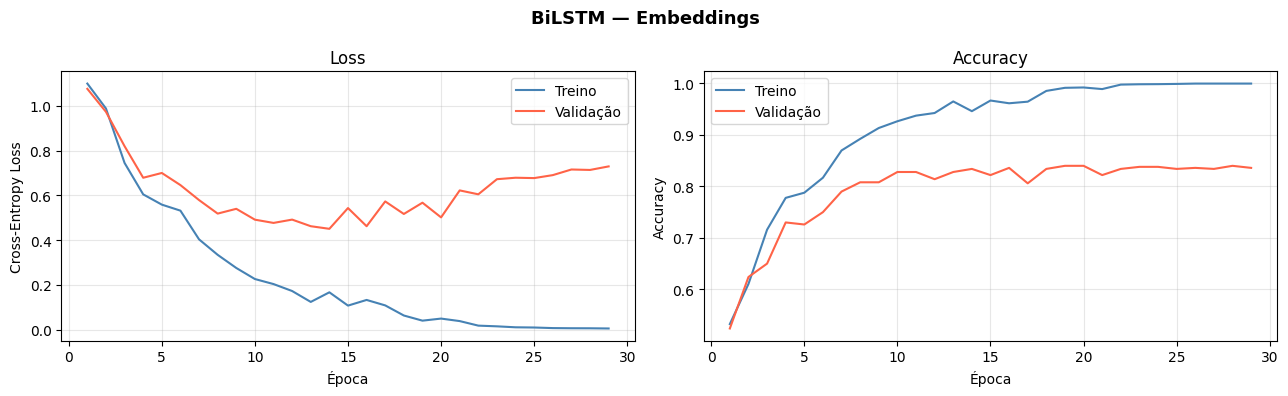


Accuracy no Teste (BiLSTM): 49.60%


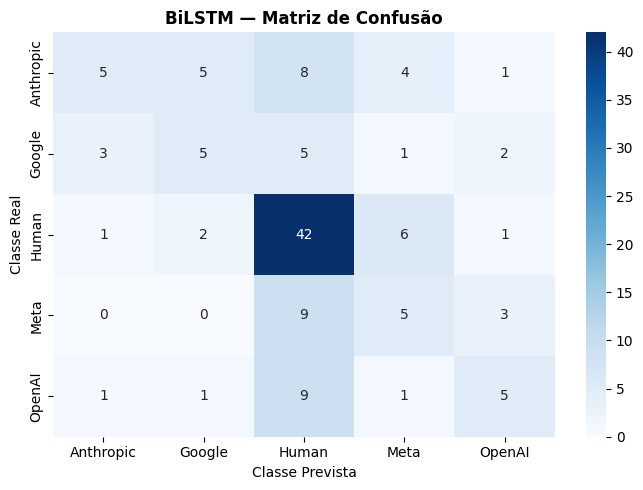

              precision    recall  f1-score   support

   Anthropic       0.50      0.22      0.30        23
      Google       0.38      0.31      0.34        16
       Human       0.58      0.81      0.67        52
        Meta       0.29      0.29      0.29        17
      OpenAI       0.42      0.29      0.34        17

    accuracy                           0.50       125
   macro avg       0.43      0.39      0.39       125
weighted avg       0.48      0.50      0.47       125



In [61]:
plot_history(history_lstm, 'BiLSTM — Embeddings')
_, acc_lstm = evaluate(lstm, test_loader_seq)
print(f"\nAccuracy no Teste (BiLSTM): {acc_lstm*100:.2f}%")
plot_confusion(lstm, test_loader_seq, 'BiLSTM — Matriz de Confusão')

---
## 5. BiGRU — Embeddings

In [62]:
gru = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=1,
    dropout=0.2,
    bidirectional=True
)

print("A treinar BiGRU (Embeddings)...")
history_gru = train(
    gru,
    train_loader_seq,
    val_loader_seq,
    criterion,
    epochs=EPOCHS,
    lr=5e-4,
    patience=PATIENCE,
    weight_decay=5e-5,
    verbose=True,
)

A treinar BiGRU (Embeddings)...
Epoch 1/100 | train_loss: 0.9506 | train_acc: 0.6158 | val_loss: 0.9268 | val_acc: 0.6080
Epoch 2/100 | train_loss: 0.7301 | train_acc: 0.7179 | val_loss: 0.7758 | val_acc: 0.6920
Epoch 3/100 | train_loss: 0.5519 | train_acc: 0.7978 | val_loss: 0.6586 | val_acc: 0.7440
Epoch 4/100 | train_loss: 0.3799 | train_acc: 0.8747 | val_loss: 0.4941 | val_acc: 0.8220
Epoch 5/100 | train_loss: 0.3453 | train_acc: 0.8803 | val_loss: 0.4912 | val_acc: 0.8280
Epoch 6/100 | train_loss: 0.2029 | train_acc: 0.9339 | val_loss: 0.4401 | val_acc: 0.8520
Epoch 7/100 | train_loss: 0.1771 | train_acc: 0.9413 | val_loss: 0.4900 | val_acc: 0.8260
Epoch 8/100 | train_loss: 0.1291 | train_acc: 0.9613 | val_loss: 0.4094 | val_acc: 0.8560
Epoch 9/100 | train_loss: 0.1396 | train_acc: 0.9617 | val_loss: 0.3886 | val_acc: 0.8620
Epoch 10/100 | train_loss: 0.1234 | train_acc: 0.9537 | val_loss: 0.5906 | val_acc: 0.8180
Epoch 11/100 | train_loss: 0.0466 | train_acc: 0.9918 | val_loss: 0

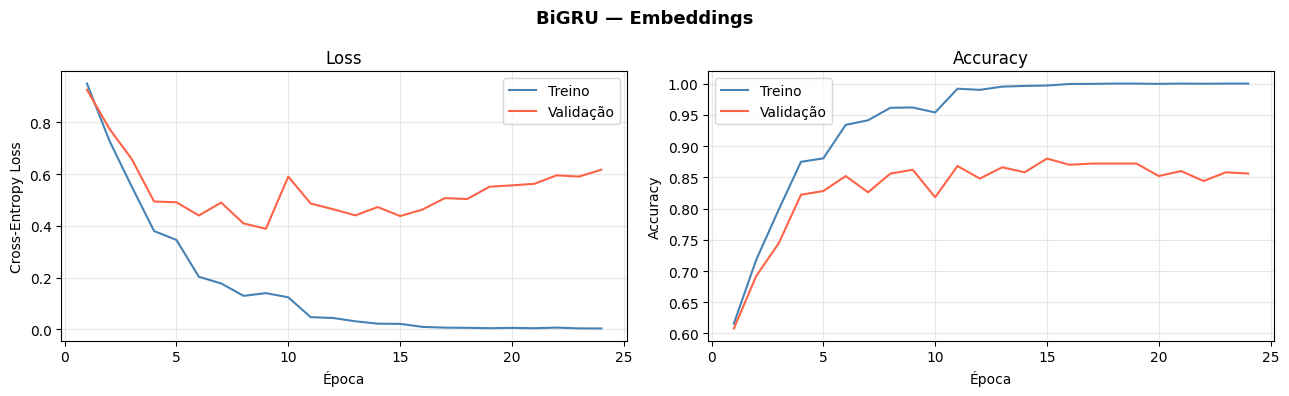


Accuracy no Teste (BiGRU): 60.80%


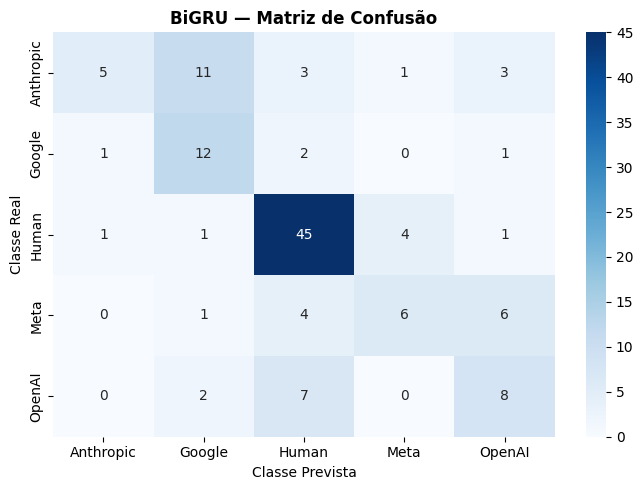

              precision    recall  f1-score   support

   Anthropic       0.71      0.22      0.33        23
      Google       0.44      0.75      0.56        16
       Human       0.74      0.87      0.80        52
        Meta       0.55      0.35      0.43        17
      OpenAI       0.42      0.47      0.44        17

    accuracy                           0.61       125
   macro avg       0.57      0.53      0.51       125
weighted avg       0.63      0.61      0.58       125



In [63]:
plot_history(history_gru, 'BiGRU — Embeddings')
_, acc_gru = evaluate(gru, test_loader_seq)
print(f"\nAccuracy no Teste (BiGRU): {acc_gru*100:.2f}%")
plot_confusion(gru, test_loader_seq, 'BiGRU — Matriz de Confusão')

---
## 6. Comparação Final dos Modelos


 COMPARAÇÃO DE MODELOS — Accuracy no Teste
  BiGRU                  60.80%  ████████████████████████
  Baseline (LogReg)      54.40%  █████████████████████
  DNN (TF-IDF)           52.00%  ████████████████████
  BiLSTM                 49.60%  ███████████████████


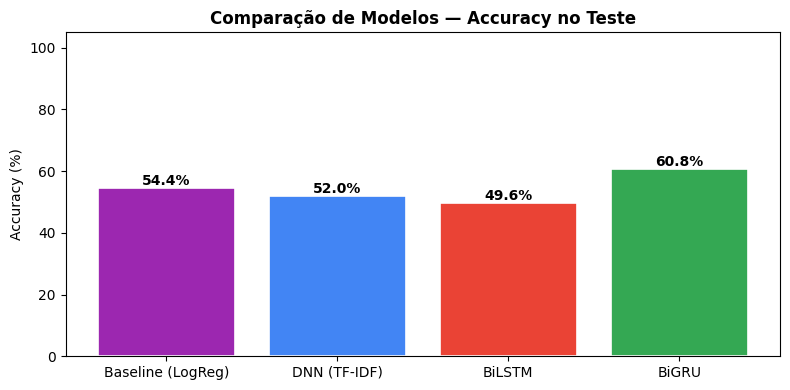

In [64]:
resultados = {
    'Baseline (LogReg)': acc_base,
    'DNN (TF-IDF)':      acc_dnn,
    'BiLSTM':            acc_lstm,
    'BiGRU':             acc_gru,
}

print("\n" + "="*45)
print(" COMPARAÇÃO DE MODELOS — Accuracy no Teste")
print("="*45)
for nome, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f"  {nome:<22} {acc*100:5.2f}%  {bar}")
print("="*45)

# Gráfico de barras
plt.figure(figsize=(8, 4))
nomes = list(resultados.keys())
accs  = [v * 100 for v in resultados.values()]
cores = ['#9C27B0', '#4285F4', '#EA4335', '#34A853']
bars  = plt.bar(nomes, accs, color=cores, edgecolor='white', linewidth=1.2)
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Comparação de Modelos — Accuracy no Teste', fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Guardar os Modelos

In [65]:
import os
save_dir = '../models/pytorch_models/saved_models'
os.makedirs(save_dir, exist_ok=True)

torch.save(baseline.state_dict(), f'{save_dir}/baseline.pt')
torch.save(dnn.state_dict(),      f'{save_dir}/dnn_tfidf.pt')
torch.save(lstm.state_dict(),     f'{save_dir}/bilstm.pt')
torch.save(gru.state_dict(),      f'{save_dir}/bigru.pt')

print("Modelos guardados em:", save_dir)

Modelos guardados em: ../models/pytorch_models/saved_models


---
## 8. Carregar e Usar um Modelo Guardado

In [70]:
# Exemplo: Carrega o BiGRU (que foi o melhor modelo) e classifcar um texto novo
model_loaded = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=1,
    dropout=0.2,
    bidirectional=True
)
model_loaded.load_state_dict(torch.load(f'{save_dir}/bigru.pt', map_location=DEVICE, weights_only=True))
model_loaded.to(DEVICE)
model_loaded.eval()

def classificar_texto(texto: str) -> str:
    if isinstance(model_loaded, DNNClassifier):
        x = train_ds_tfidf.vectorizer.transform([texto]).toarray()
        x_tensor = torch.tensor(x, dtype=torch.float32, device=DEVICE)
    else:
        tokens = clean_text(texto).split()
        seq = [word_index.get(word, 1) for word in tokens][:MAX_LEN]
        if len(seq) < MAX_LEN:
            seq += [0] * (MAX_LEN - len(seq))
        x_tensor = torch.tensor([seq], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        logits = model_loaded(x_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()

    pred_idx = probs.argmax().item()
    print(f"Classe prevista: {CLASSES[pred_idx]}")
    print("Probabilidades:")
    for cls, p in zip(CLASSES, probs.tolist()):
        bar = '█' * int(p * 30)
        print(f"  {cls:<10} {p*100:5.1f}%  {bar}")
    return CLASSES[pred_idx]

# Testar com um texto
texto_teste = "The carbon cycle is a biogeochemical cycle where carbon is exchanged between the Earth's biosphere, atmosphere, and oceans."
classificar_texto(texto_teste)

Classe prevista: Human
Probabilidades:
  Anthropic    0.2%  
  Google       0.2%  
  Human       99.4%  █████████████████████████████
  Meta         0.2%  
  OpenAI       0.0%  


'Human'

---
## 9. Gerar Ficheiro de Submissão B (PyTorch)

Este passo lê o ficheiro `subm1.csv`, que contém apenas os textos de teste sem labels, carrega um dos modelos PyTorch treinados (neste caso, o **DNN**) e prevê a classe para cada texto. O resultado é depois exportado para `Subm1/subm1-g3-MIA-B.csv`.

In [72]:
import os
import pandas as pd
import torch

# 1. Ler o ficheiro de teste
subm_path = '../subm1.csv'
df_subm = pd.read_csv(subm_path, sep=';')

# 2. Converter textos para sequências de índices (BiGRU)
def encode_for_bigru(texto: str) -> list[int]:
    tokens = clean_text(texto).split()
    seq = [word_index.get(word, 1) for word in tokens][:MAX_LEN]  # 1 = UNK
    if len(seq) < MAX_LEN:
        seq += [0] * (MAX_LEN - len(seq))                          # 0 = PAD
    return seq

X_subm_seq = [encode_for_bigru(text) for text in df_subm['Text'].tolist()]
X_subm_tensor = torch.tensor(X_subm_seq, dtype=torch.long, device=DEVICE)

# 3. Carregar o modelo guardado (BiGRU foi o melhor modelo em Accuracy)
model_subm = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=1,
    dropout=0.2,
    bidirectional=True
)
model_subm.load_state_dict(torch.load(f'{save_dir}/bigru.pt', map_location=DEVICE, weights_only=True))
model_subm.to(DEVICE)
model_subm.eval()

# 4. Fazer predições
with torch.no_grad():
    logits_subm = model_subm(X_subm_tensor)
    probs_subm = torch.softmax(logits_subm, dim=1)
    preds_idx = probs_subm.argmax(dim=1).cpu().numpy()

# 5. Mapear os índices para as labels correspondentes
predicted_labels = [idx2label[idx] for idx in preds_idx]

# 6. Criar o DataFrame final
df_final_b = pd.DataFrame({
    'ID': df_subm['ID'],
    'Text': df_subm['Text'],
    'Label': predicted_labels
})

# 7. Guardar no diretório Subm1
output_dir = '../Subm1'
os.makedirs(output_dir, exist_ok=True)
output_filename = os.path.join(output_dir, 'subm1-g3-MIA-B.csv')

df_final_b.to_csv(output_filename, sep=';', index=False)

print(f"Ficheiro de submissão criado com sucesso: {output_filename}")
print(df_final_b.head())

Ficheiro de submissão criado com sucesso: ../Subm1/subm1-g3-MIA-B.csv
     ID                                               Text   Label
0  D2-1  A covalent bond is a chemical bond that involv...   Human
1  D2-2  A covalent bond forms when two atoms share one...  OpenAI
2  D2-3  A covalent bond is a type of chemical bond whe...  OpenAI
3  D2-4  A covalent bond is a chemical bond that involv...    Meta
4  D2-5  Driven by exciting developments in the field o...   Human
